In [1]:
import wandb
import pandas as pd
import numpy as np
import json
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(path="harvardml/opt-olmo")

In [4]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',   'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [5]:
df = pd.DataFrame()

max_steps = [6200, 12500, 25000, 50000]
groups =  ["bs-all-1", "wd-all-4", "wd-all-5", "beta-all-1", "eps-all-1", "warmup-all-1", "momentum-all-1"]
plot_key = "learning_rate"
display_key = "Learning Rate"

for run in runs:
    if run.group in groups:
        history = run.history(samples=25000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        if "wd" in run.group:
            run_dict["group"] = "weight_decay"
        elif "bs" in run.group:
            run_dict["group"] = "batch_size"
        elif "beta" in run.group:
            run_dict["group"] = "beta_1"
        elif "momentum" in run.group:
            run_dict["group"] = "beta_0"
        elif "eps" in run.group:
            run_dict["group"] = "eps"
        elif "warmup" in run.group:
            run_dict["group"] = "warmup"

        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict[plot_key] = run.config["optimizer"][plot_key]

        run_dict["warmup"] = run.config["scheduler"]["t_warmup"]
        run_dict["batch_size"] = run.config["global_train_batch_size"]
        run_dict["weight_decay"] = run.config["optimizer"]["weight_decay"]
        run_dict["beta_1"] = run.config["optimizer"]["beta_1"]
        run_dict["beta_0"] = run.config["optimizer"]["beta_0"]
        run_dict["eps"] = run.config["optimizer"]["eps"]

        if "eval/c4_val/CrossEntropyLoss" in history:
            step = max(list(history["_step"]))
            if step not in max_steps:
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [6]:
df

,id,group,optimizer,learning_rate,warmup,batch_size,weight_decay,beta_1,beta_0,eps,val_loss,step
0,xyz12ajk,batch_size,lionw,0.000316,625,1024,0.0,0.95,0.90,1.000000e-15,3.114631,6200.0
0,keysmmyh,batch_size,signsgd,0.000316,625,1024,0.0,0.95,0.90,1.000000e-15,3.123382,6200.0
0,kijthn6a,weight_decay,novagradw_ours,0.003160,2500,256,10.0,0.95,0.90,1.000000e-15,7.162034,25000.0
0,rece9prn,weight_decay,novagradw_ours,0.003160,2500,256,1.0,0.95,0.90,1.000000e-15,4.109503,25000.0
0,dldem3qi,weight_decay,adafactorw,0.003160,2500,256,100.0,0.95,0.90,1.000000e-15,10.227961,25000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
0,6h93lc9b,beta_0,lionw,0.000316,2500,256,0.0,0.95,0.80,1.000000e-15,3.088297,25000.0
0,02v4uzxk,beta_0,signsgd,0.000316,2500,256,0.0,0.95,0.95,1.000000e-15,3.072563,25000.0
0,qaju3tdr,beta_0,sgdw,1.000000,2500,256,0.0,0.95,0.90,1.000000e-15,3.297276,25000.0
0,6lrm4evq,beta_0,sgdw,1.000000,2500,256,0.0,0.95,0.80,1.000000e-15,3.402063,25000.0


In [7]:
df["optimizer"].unique()

array(['lionw', 'signsgd', 'novagradw_ours', 'adafactorw', 'sgdw',
       'adamw', 'sophiag', 'adafactorw_oneside'], dtype=object)

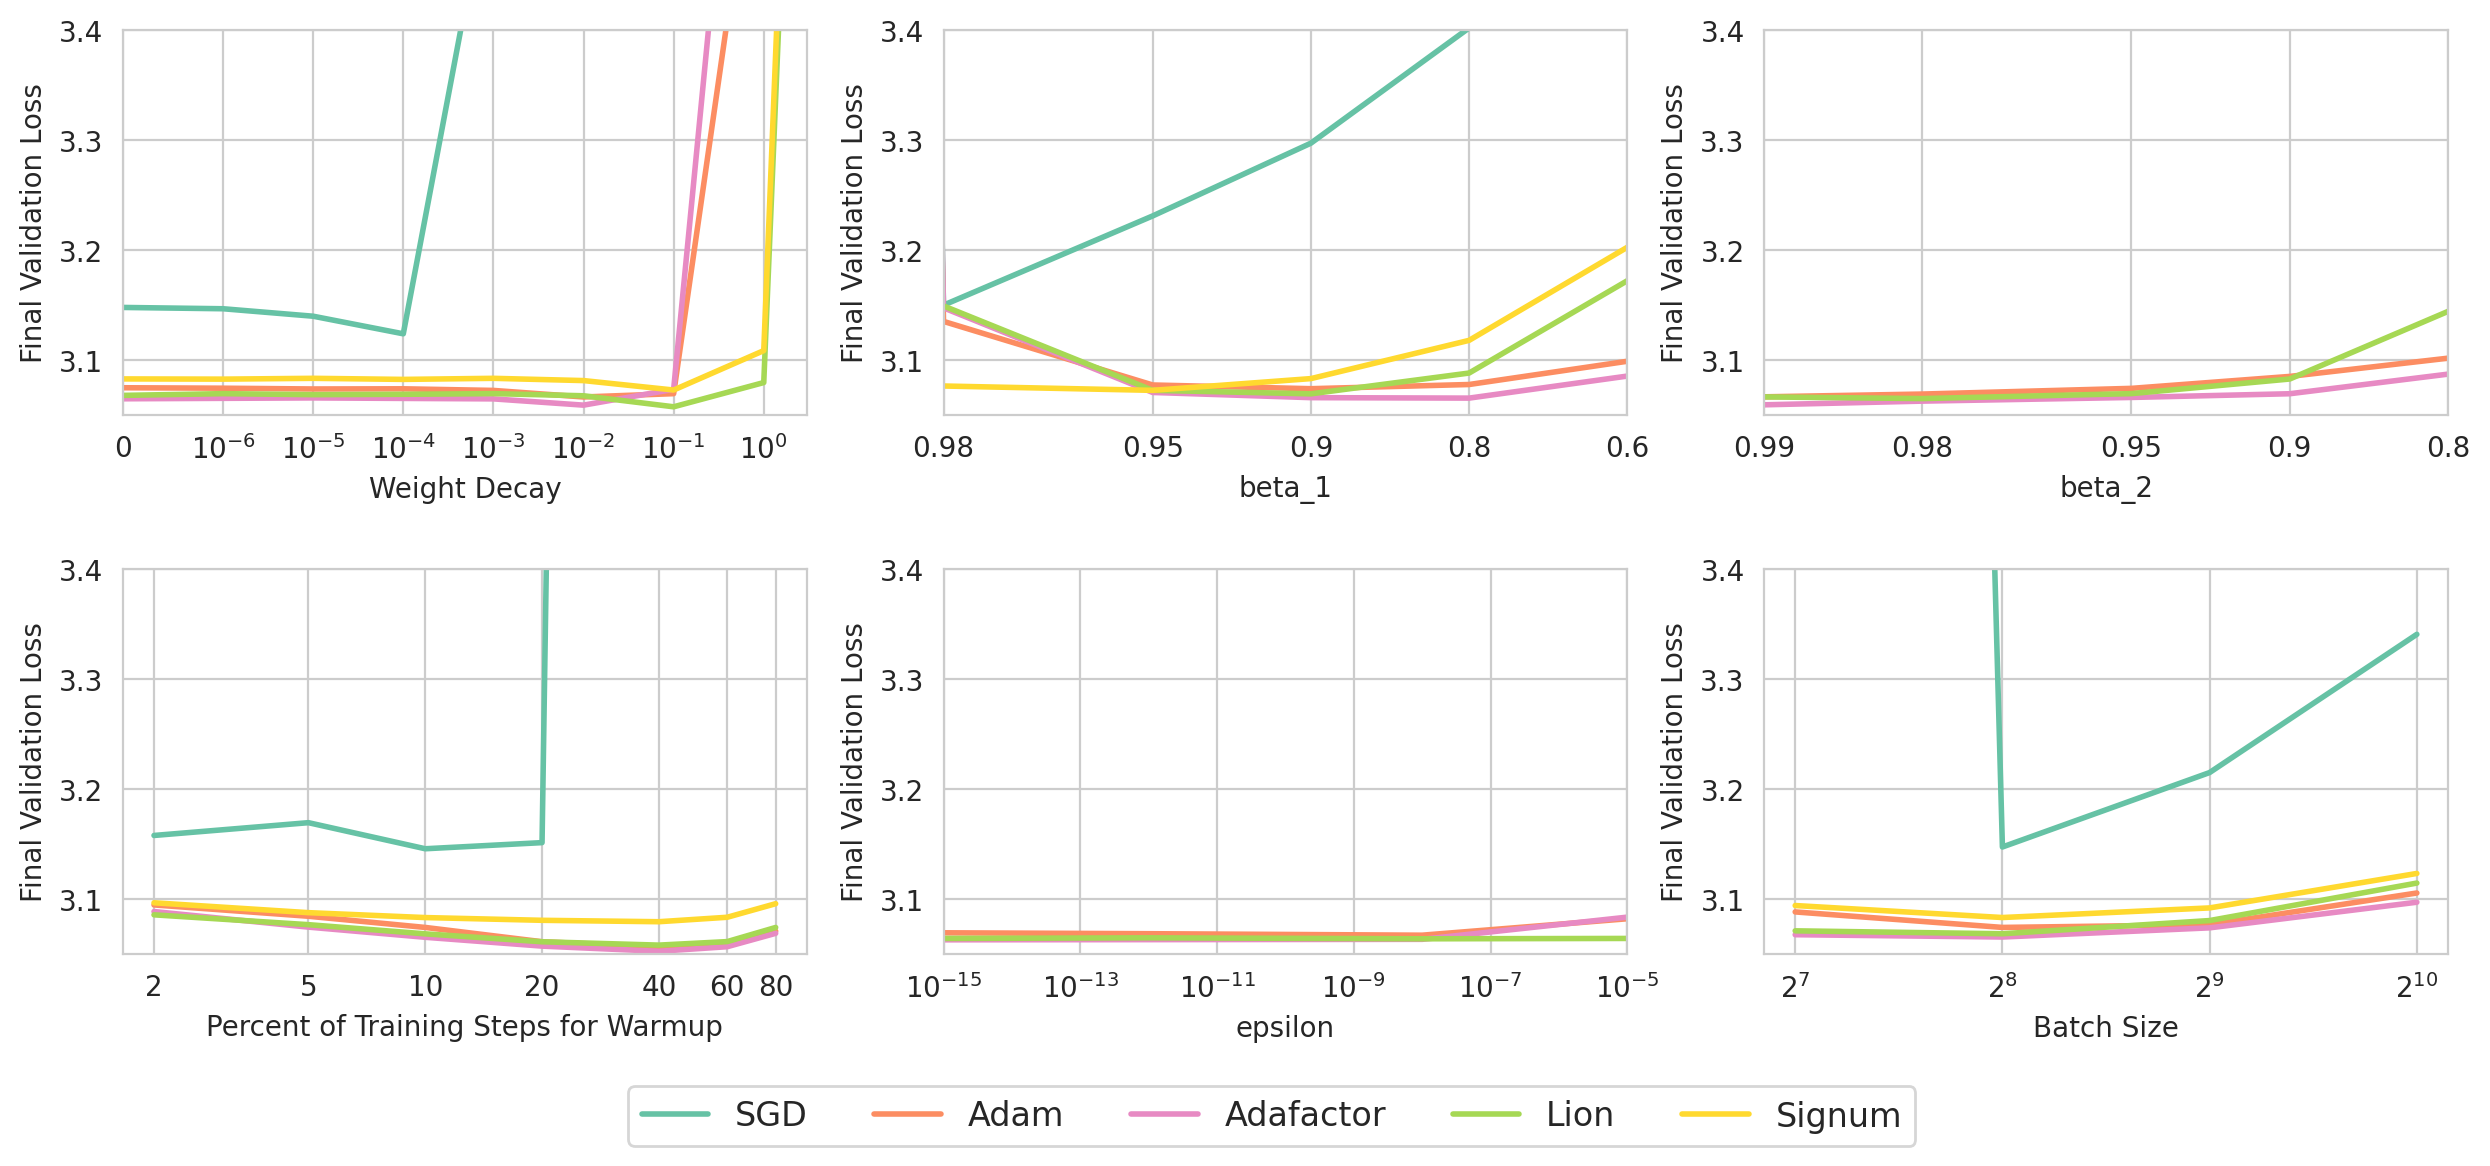

In [17]:
sns.set_style("whitegrid")
#plt.figure(figsize=(15, 3), dpi=200)  # Larger figure size
fig, axs = plt.subplots(2, 3, figsize=(15, 6), dpi=200)

axs = axs.flatten()

# adjust vertical space
plt.subplots_adjust(hspace=0.4)

for i, group in enumerate(["weight_decay", "beta_0", "beta_1", "warmup", "eps", "batch_size"]):

    ax = axs[i]
    group_df = df[df["group"] == group]

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours", "adafactorw_oneside"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by=group)
            optimizer_df = optimizer_df.groupby(group).min().reset_index()
            if group == "warmup":
                x = optimizer_df["warmup"] / 250
            elif group in ["beta_1", "beta_0"]:
                x = 1 - optimizer_df[group]
            else:
                x = optimizer_df[group]

            ax.plot(x, optimizer_df["val_loss"], 
                    label=name_map[optimizer],
                    linewidth=2,
                    color=color_map[optimizer],
                    #linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )

    if group == "warmup":
        ax.set_xscale("log")
        ax.set_xticks([2, 5, 10, 20, 40, 60, 80], [2, 5, 10, 20, 40, 60, 80])
        ax.set_xlabel("Percent of Training Steps for Warmup")
    elif group == "batch_size":
        ax.set_xscale("log", base = 2)
        ax.set_xlabel("Batch Size")
    elif group == "beta_1":
        ax.set_xscale("log")
        ax.set_xlabel("beta_2")
        ax.set_xlim(0.01, 0.2)
        xs = [0.8, 0.9, 0.95, 0.98, 0.99][::-1]
        xsa = 1 - np.array(xs)
        ax.set_xticks(xsa, xs)
    elif group == "beta_0":
        ax.set_xscale("log")
        ax.set_xlabel("beta_1")
        ax.set_xlim(0.02, 0.4)
        xs = [0.6, 0.8, 0.9, 0.95, 0.98][::-1]
        xsa = 1 - np.array(xs)
        ax.set_xticks(xsa, xs)
    elif group == "eps":
        ax.set_xscale("log")
        ax.set_xlabel("epsilon")
        ax.set_xlim(1e-15, 1e-5)
    elif group == "weight_decay":
        ax.set_xscale("symlog", linthresh=1e-6)
        ax.set_xlabel("Weight Decay")
        ax.set_xlim(0, 3)


    ax.set_ylim(3.05, 3.4)
    ax.set_ylabel("Final Validation Loss")


axs[5].legend(loc='upper center', bbox_to_anchor=(-0.72, -0.3), fancybox=True, shadow=False, ncol=5, fontsize=12)

# fig.delaxes(axs[-1])

plt.savefig('../figures/others.png', bbox_inches='tight')
plt.show()